In [5]:
import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import pandas as pd
load_dotenv()

True

## Load data

In [2]:
# Selected LGAs in Borno state
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet"
)

In [7]:
# IMERG
engine = stratus.get_engine("prod")
pcodes = list(gdf_lga_sel['ADM2_PCODE'])

with engine.connect() as conn:
    query = """
        SELECT * 
        FROM imerg
        WHERE pcode IN %(pcodes)s
    """
    df_imerg = pd.read_sql(query, engine, params={'pcodes': tuple(pcodes)}, parse_dates=["valid_date"])
stratus.upload_parquet_to_blob(df_imerg, "ds-aa-nga-flooding/processed/imerg/imerg_hfr_lgas_borno.parquet")

In [8]:
df_imerg = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/imerg/imerg_hfr_lgas_borno.parquet")

In [10]:
df_imerg

,iso3,pcode,valid_date,adm_level,mean,median,min,max,count,sum,std
0,NGA,NG008016,2013-09-06,2,2.370773,1.0900,0.00,17.675,194,459.930,3.613440
1,NGA,NG008025,2014-01-05,2,0.000000,0.0000,0.00,0.000,49,0.000,0.000000
2,NGA,NG008008,2014-01-11,2,0.000000,0.0000,0.00,0.000,61,0.000,0.000000
3,NGA,NG036003,2014-02-26,2,0.000000,0.0000,0.00,0.000,75,0.000,0.000000
4,NGA,NG008008,2014-02-26,2,0.000000,0.0000,0.00,0.000,61,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
165371,NGA,NG036008,2026-04-20,2,0.106818,0.0375,0.00,0.545,66,7.050,0.150075
165372,NGA,NG008013,2026-04-20,2,0.200357,0.1225,0.01,0.565,28,5.610,0.201011
165373,NGA,NG008014,2026-04-20,2,0.441494,0.3050,0.00,1.790,87,38.410,0.474222
165374,NGA,NG008015,2026-04-20,2,0.000000,0.0000,0.00,0.000,65,0.000,0.000000


In [9]:
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet")

In [11]:
df_floodscan

,iso3,pcode,valid_date,adm_level,band,mean,median,min,max,count,sum,std
0,NGA,NG036003,2022-11-01,2,SFED,0.000000,0.0,0.0,0.000000,80,0.000000,0.000000
1,NGA,NG008008,2022-11-01,2,SFED,0.000000,0.0,0.0,0.000000,63,0.000000,0.000000
2,NGA,NG008009,2022-11-01,2,SFED,0.000002,0.0,0.0,0.000100,87,0.000200,0.000015
3,NGA,NG036007,2022-11-01,2,SFED,0.000000,0.0,0.0,0.000000,113,0.000000,0.000000
4,NGA,NG036008,2022-11-01,2,SFED,0.000000,0.0,0.0,0.000000,72,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
165211,NGA,NG008014,2022-10-31,2,SFED,0.000000,0.0,0.0,0.000000,83,0.000000,0.000000
165212,NGA,NG008015,2022-10-31,2,SFED,0.001836,0.0,0.0,0.016935,61,0.111973,0.004013
165213,NGA,NG008023,2022-10-31,2,SFED,0.036641,0.0,0.0,0.487937,90,3.297728,0.105441
165214,NGA,NG008024,2022-10-31,2,SFED,0.008811,0.0,0.0,0.223600,65,0.572726,0.041269


## Cross-correlation: IMERG precipitation vs Floodscan SFED

Per LGA, compute Pearson correlation between daily precipitation anomalies and SFED anomalies at multiple lags. Positive lag = precipitation leads flooding.

In [15]:
from scipy import stats as scipy_stats
import numpy as np

MAX_LAG = 14
MIN_LAG = -7
MIN_OBS = 60

# Prepare both datasets
df_pr = df_imerg.copy()
df_pr["date"] = pd.to_datetime(df_pr["valid_date"]).dt.normalize()
df_pr = df_pr.rename(columns={"mean": "precip"})

df_fs = df_floodscan.copy()
df_fs["date"] = pd.to_datetime(df_fs["valid_date"]).dt.normalize()
df_fs = df_fs.rename(columns={"mean": "sfed"})

results = []

for pcode in gdf_lga_sel["ADM2_PCODE"].unique():
    lga_name = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]

    df_p = df_pr[df_pr["pcode"] == pcode][["date", "precip"]].copy()
    df_s = df_fs[df_fs["pcode"] == pcode][["date", "sfed"]].copy()

    df_merged = df_p.merge(df_s, on="date").dropna(subset=["precip", "sfed"])
    if len(df_merged) < MIN_OBS:
        continue

    best_r, best_lag, best_p = 0.0, 0, 1.0
    lag_rs = {}
    for lag in range(MIN_LAG, MAX_LAG + 1):
        sfed_shifted = df_merged["sfed"].shift(-lag)
        valid = df_merged["precip"].notna() & sfed_shifted.notna()
        if valid.sum() < MIN_OBS:
            continue
        r, p = scipy_stats.pearsonr(df_merged["precip"][valid], sfed_shifted[valid])
        lag_rs[lag] = r
        if abs(r) > abs(best_r):
            best_r, best_lag, best_p = r, lag, p

    results.append({
        "pcode": pcode,
        "lga_name": lga_name,
        "best_r": best_r,
        "best_lag_days": best_lag,
        "best_p": best_p,
        "lag_profile": lag_rs,
        "n_obs": len(df_merged),
    })

df_results = pd.DataFrame(results).sort_values("best_r", ascending=False).reset_index(drop=True)
print(f"Correlations computed for {len(df_results)} LGAs")
df_results[["lga_name", "best_r", "best_lag_days", "best_p", "n_obs"]]

Correlations computed for 16 LGAs


,lga_name,best_r,best_lag_days,best_p,n_obs
0,Ngala,0.303964,1,1.315551e-219,10325
1,Kala/Balge,0.279620,2,9.703016e-185,10325
2,Dikwa,0.276827,2,5.833700e-181,10325
3,Mafa,0.257181,2,1.313704e-155,10325
4,Jere,0.121840,2,1.935052e-35,10325
5,Kaga,0.102821,3,1.151207e-25,10325
6,Maiduguri,0.096484,9,9.111851e-23,10325
7,Konduga,0.094178,2,8.903400e-22,10325
8,Damaturu,0.088233,2,2.680260e-19,10325
9,Gulani,0.068463,1,3.316307e-12,10325


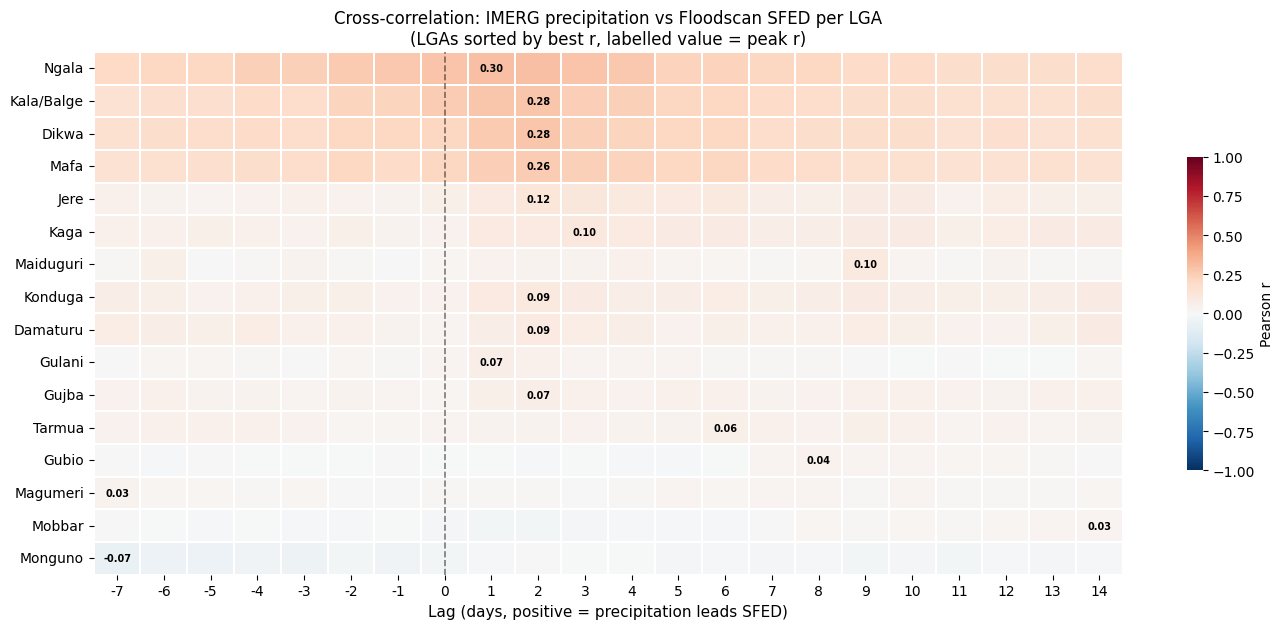

In [16]:
import seaborn as sns

# --- Lag-correlation heatmap: one row per LGA ---
lags = list(range(MIN_LAG, MAX_LAG + 1))

lag_matrix = pd.DataFrame(
    [row["lag_profile"] for _, row in df_results.iterrows()],
    index=df_results["lga_name"],
    columns=lags,
)

fig, ax = plt.subplots(figsize=(14, max(4, len(df_results) * 0.4)))

sns.heatmap(
    lag_matrix,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.6},
)

# Label best-correlation cell per LGA
for row_idx, (_, row) in enumerate(df_results.iterrows()):
    best_lag = row["best_lag_days"]
    best_r = row["best_r"]
    if best_lag in lags:
        col_idx = lags.index(best_lag)
        ax.text(
            col_idx + 0.5, row_idx + 0.5,
            f"{best_r:.2f}",
            ha="center", va="center",
            fontsize=7, fontweight="bold",
            color="white" if abs(best_r) > 0.5 else "black",
        )

ax.axvline(x=lags.index(0) + 0.5, color="black", linewidth=1.2, linestyle="--", alpha=0.5)
ax.set_xlabel("Lag (days, positive = precipitation leads SFED)", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Cross-correlation: IMERG precipitation vs Floodscan SFED per LGA\n(LGAs sorted by best r, labelled value = peak r)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("figures/imerg_sfed_lag_heatmap.png", dpi=200, bbox_inches="tight")

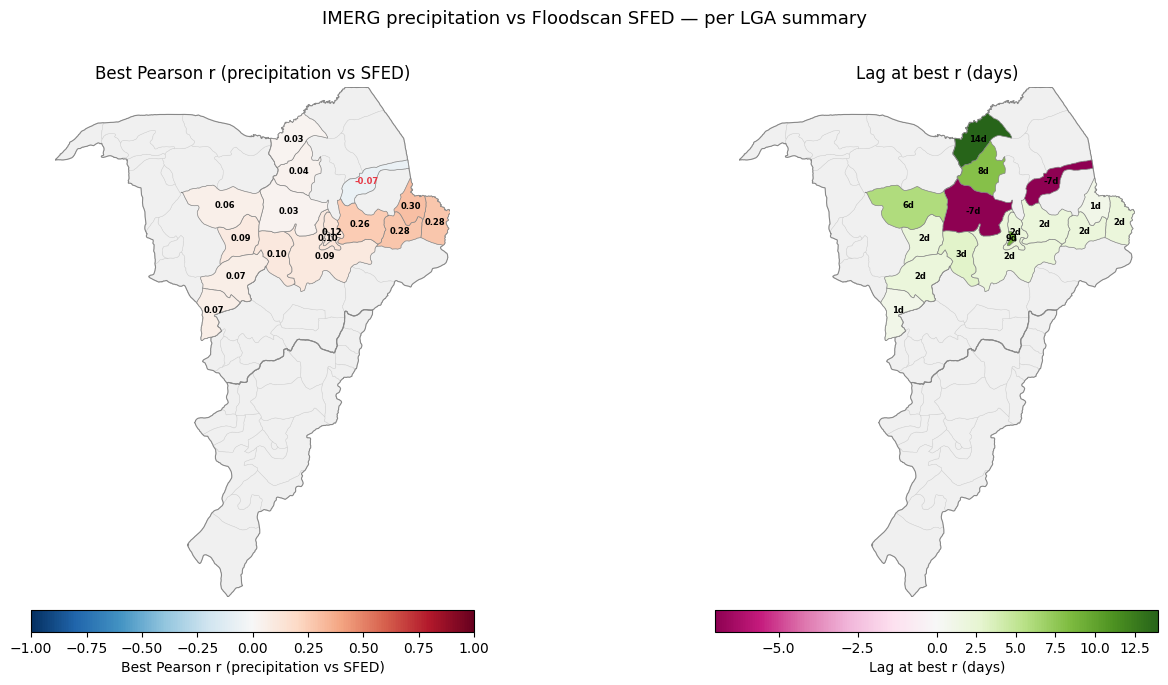

In [19]:
import matplotlib.colors as mcolors

gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_codab = stratus.codab.load_codab_from_blob("NGA", admin_level=0)

bay_states = ["Borno", "Adamawa", "Yobe"]
gdf_lga_bay = gdf_lga[gdf_lga["ADM1_EN"].isin(bay_states)]
gdf_adm1_bay = gdf_lga_bay.dissolve(by="ADM1_EN").reset_index()

gdf_lga_choropleth = gdf_lga_sel.merge(
    df_results[["pcode", "best_r", "best_lag_days"]],
    left_on="ADM2_PCODE", right_on="pcode", how="left"
)

r_norm = mcolors.Normalize(vmin=-1, vmax=1)
lag_norm = mcolors.TwoSlopeNorm(vmin=MIN_LAG, vcenter=0, vmax=MAX_LAG)

xmin, ymin, xmax, ymax = gdf_lga_bay.total_bounds

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, title, cmap, norm in zip(
    axes,
    ["best_r", "best_lag_days"],
    ["Best Pearson r (precipitation vs SFED)", "Lag at best r (days)"],
    ["RdBu_r", "PiYG"],
    [r_norm, lag_norm],
):
    gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
    gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)

    gdf_lga_choropleth.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        norm=norm,
        edgecolor="#888888",
        linewidth=0.5,
        legend=True,
        legend_kwds={"label": title, "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
        missing_kwds={"color": "#cccccc", "edgecolor": "#888888", "label": "No data"},
        zorder=3,
    )

    for _, row in gdf_lga_choropleth.iterrows():
        if pd.notna(row[col]):
            centroid = row.geometry.centroid
            val = row[col]
            if col == "best_r":
                label = f"{val:.2f}"
                color = "#E63946" if val < 0 else ("white" if val > 0.5 else "black")
            else:
                label = f"{int(val)}d"
                color = "black"
            ax.text(centroid.x, centroid.y, label, ha="center", va="center",
                    fontsize=6, fontweight="bold", color=color)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

plt.suptitle("IMERG precipitation vs Floodscan SFED — per LGA summary", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/imerg_sfed_choropleth.png", dpi=200, bbox_inches="tight")

## Correlation: 10-day cumulative IMERG vs Floodscan SFED

In [ ]:
results_10d = []

for pcode in gdf_lga_sel["ADM2_PCODE"].unique():
    lga_name = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]

    df_p = df_pr[df_pr["pcode"] == pcode][["date", "precip"]].copy().sort_values("date")
    df_s = df_fs[df_fs["pcode"] == pcode][["date", "sfed"]].copy()

    # 10-day rolling sum shifted by 1 so the window ends the day before the SFED date
    df_p["precip_10d"] = df_p["precip"].rolling(10).sum().shift(1)

    df_merged = df_p.merge(df_s, on="date").dropna(subset=["precip_10d", "sfed"])
    if len(df_merged) < MIN_OBS:
        continue

    r, p = scipy_stats.pearsonr(df_merged["precip_10d"], df_merged["sfed"])
    results_10d.append({
        "pcode": pcode,
        "lga_name": lga_name,
        "r": r,
        "p": p,
        "n_obs": len(df_merged),
    })

df_10d = pd.DataFrame(results_10d).sort_values("r", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(df_10d) * 0.35)))
colors = ["#E63946" if r < 0 else "#007CE0" for r in df_10d["r"]]
ax.barh(df_10d["lga_name"], df_10d["r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r")
ax.set_title("Correlation: 10-day cumulative IMERG (preceding) vs Floodscan SFED — per LGA")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

df_10d[["lga_name", "r", "p", "n_obs"]]

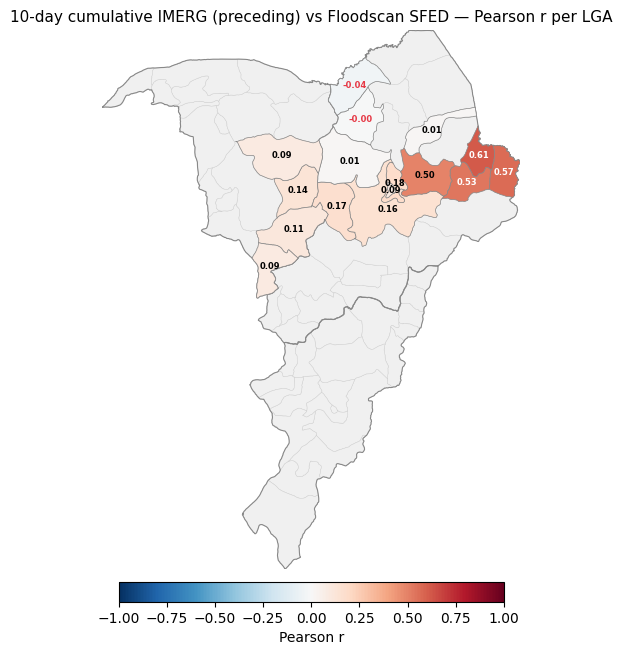

In [21]:
gdf_10d = gdf_lga_sel.merge(
    df_10d[["pcode", "r"]], left_on="ADM2_PCODE", right_on="pcode", how="left"
)

bay_states = ["Borno", "Adamawa", "Yobe"]
gdf_lga_bay = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_lga_bay = gdf_lga_bay[gdf_lga_bay["ADM1_EN"].isin(bay_states)]
gdf_adm1_bay = gdf_lga_bay.dissolve(by="ADM1_EN").reset_index()
xmin, ymin, xmax, ymax = gdf_lga_bay.total_bounds

fig, ax = plt.subplots(figsize=(8, 7))

gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_10d.plot(
    ax=ax, column="r",
    cmap="RdBu_r", norm=mcolors.Normalize(vmin=-1, vmax=1),
    edgecolor="#888888", linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Pearson r", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
    missing_kwds={"color": "#cccccc", "edgecolor": "#888888", "label": "No data"},
    zorder=3,
)

for _, row in gdf_10d.iterrows():
    if pd.notna(row["r"]):
        centroid = row.geometry.centroid
        val = row["r"]
        color = "#E63946" if val < 0 else ("white" if val > 0.5 else "black")
        ax.text(centroid.x, centroid.y, f"{val:.2f}",
                ha="center", va="center", fontsize=6, fontweight="bold", color=color)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("10-day cumulative IMERG (preceding) vs Floodscan SFED — Pearson r per LGA", fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/imerg_10d_sfed_choropleth.png", dpi=200, bbox_inches="tight")

## Annual return period comparison: IMERG vs Floodscan

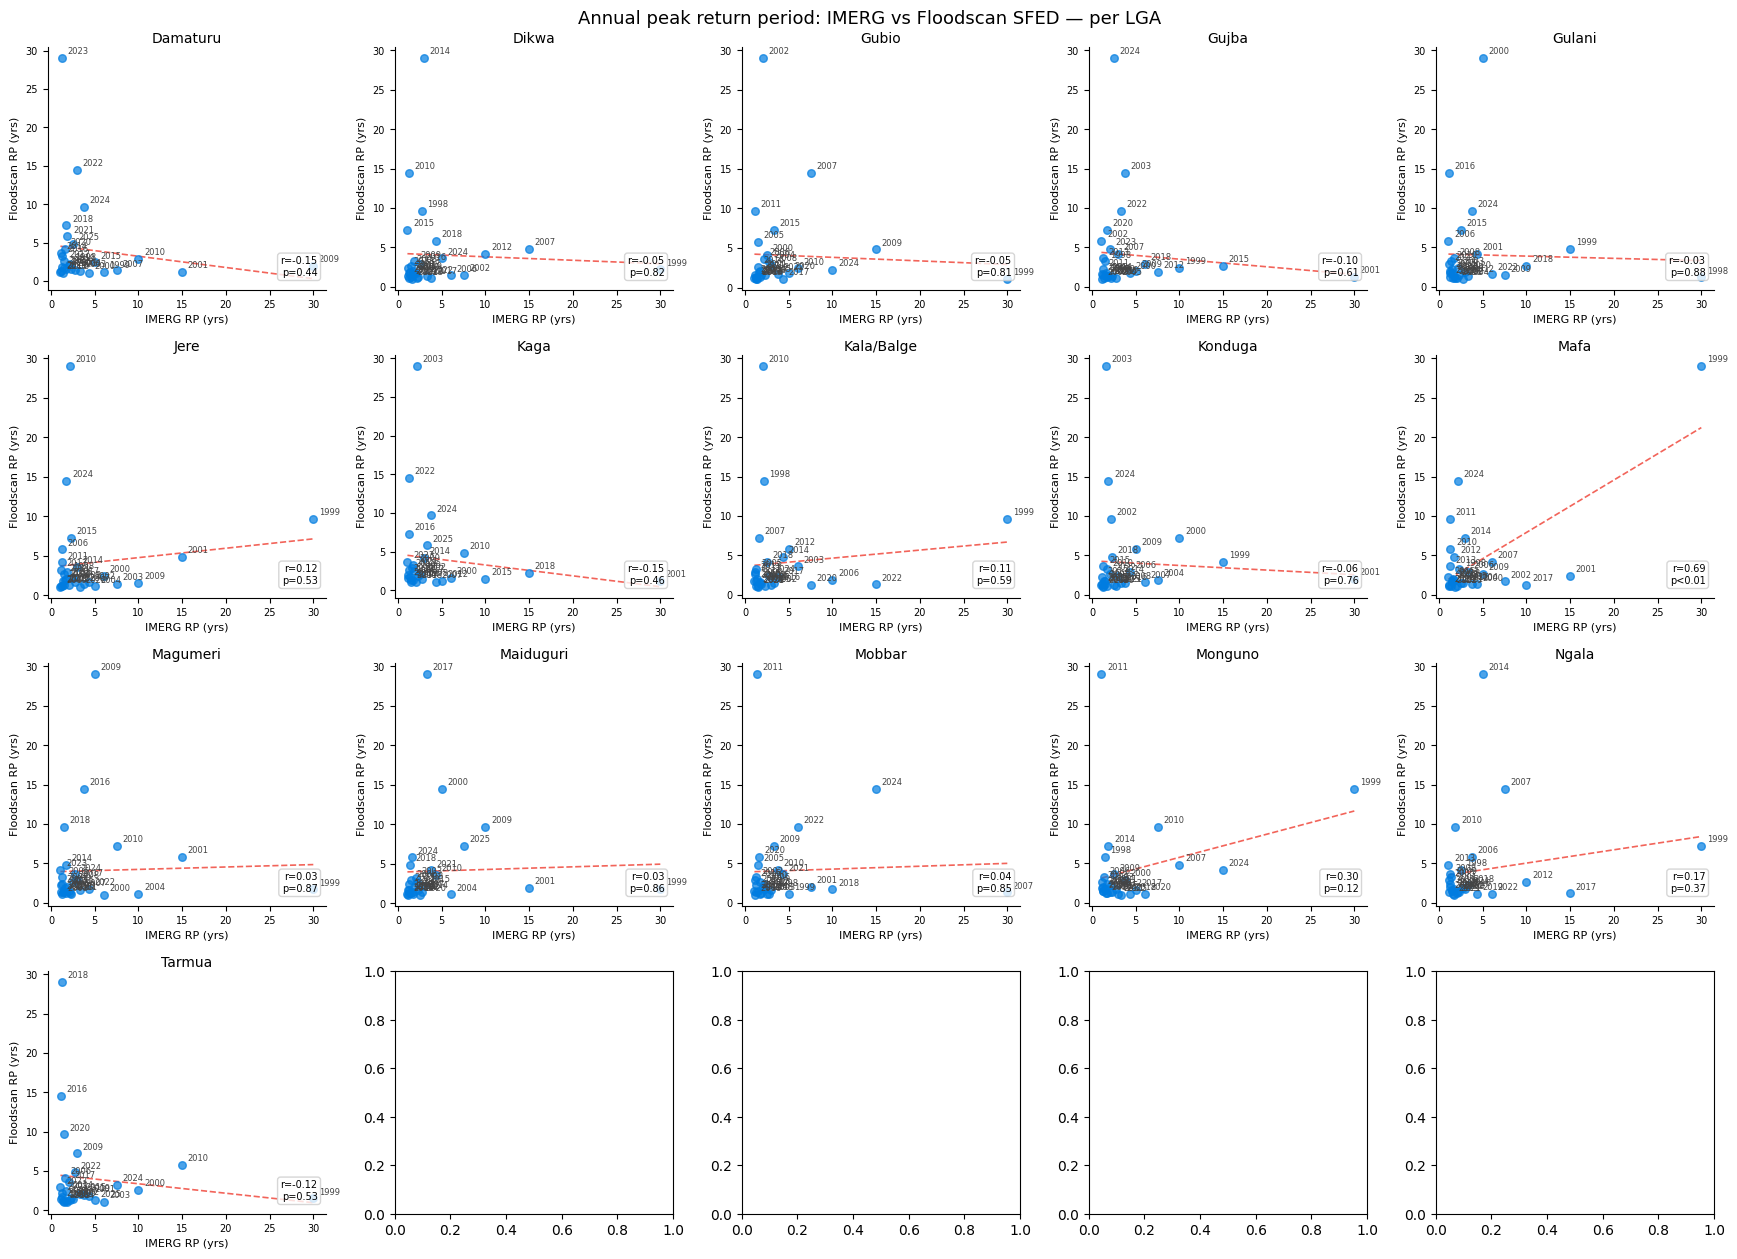

In [14]:
from src.utils import rp_calc

# Annual max IMERG per LGA → return periods
df_imerg_ann = df_imerg.copy()
df_imerg_ann["year"] = pd.to_datetime(df_imerg_ann["valid_date"]).dt.year
df_imerg_max = df_imerg_ann.groupby(["pcode", "year"])["mean"].max().reset_index()
df_imerg_rp = rp_calc.calculate_groups_rp(df_imerg_max, by=["pcode"], col_name="mean", ascending=False)
df_imerg_rp = df_imerg_rp.rename(columns={"mean_rp": "imerg_rp"})

# Annual max Floodscan SFED per LGA → return periods
df_fs_ann = df_floodscan.copy()
df_fs_ann["year"] = pd.to_datetime(df_fs_ann["valid_date"]).dt.year
df_fs_ann = df_fs_ann[df_fs_ann["year"] != 2026]
df_fs_max = df_fs_ann.groupby(["pcode", "year"])["mean"].max().reset_index()
df_fs_rp = rp_calc.calculate_groups_rp(df_fs_max, by=["pcode"], col_name="mean", ascending=False)
df_fs_rp = df_fs_rp.rename(columns={"mean_rp": "fs_rp"})

df_rp_compare = (
    df_imerg_rp[["pcode", "year", "imerg_rp"]]
    .merge(df_fs_rp[["pcode", "year", "fs_rp"]], on=["pcode", "year"])
    .dropna()
)

# Facet: one scatter per LGA
lgas = gdf_lga_sel[["ADM2_PCODE", "ADM2_EN"]].drop_duplicates().sort_values("ADM2_EN")
pcodes = [p for p in lgas["ADM2_PCODE"] if p in df_rp_compare["pcode"].values]

ncols = 5
nrows = (len(pcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2), squeeze=False)
axes_flat = axes.flat

for ax, pcode in zip(axes_flat, pcodes):
    lga_name = lgas.loc[lgas["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    sub = df_rp_compare[df_rp_compare["pcode"] == pcode]

    ax.scatter(sub["imerg_rp"], sub["fs_rp"], color="#007CE0", s=30, zorder=3, alpha=0.7)

    for _, row in sub.iterrows():
        ax.annotate(str(int(row["year"])), (row["imerg_rp"], row["fs_rp"]),
                    textcoords="offset points", xytext=(4, 3), fontsize=6, color="#444444")

    if len(sub) >= 3:
        m, b, r, p, _ = scipy_stats.linregress(sub["imerg_rp"], sub["fs_rp"])
        x_line = np.linspace(sub["imerg_rp"].min(), sub["imerg_rp"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.2, linestyle="--")
        p_str = "p<0.01" if p < 0.01 else f"p={p:.2f}"
        ax.text(0.97, 0.05, f"r={r:.2f}\n{p_str}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=7,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.8))

    ax.set_title(lga_name, fontsize=10, pad=3)
    ax.set_xlabel("IMERG RP (yrs)", fontsize=8)
    ax.set_ylabel("Floodscan RP (yrs)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

for ax in list(axes_flat)[len(pcodes):]:
    ax.set_visible(False)

fig.suptitle("Annual peak return period: IMERG vs Floodscan SFED — per LGA", fontsize=13)
plt.tight_layout()
plt.savefig("figures/imerg_sfed_rp_facet.png", dpi=200, bbox_inches="tight")